In [1]:
import jax
import jax.numpy as np
import zodiax as zdx
import dLux as dl
import optax

import matplotlib.pyplot as plt

dLux: Jax is running in 32-bit, to enable 64-bit visit: https://jax.readthedocs.io/en/latest/notebooks/Common_Gotchas_in_JAX.html#double-64bit-precision


In [2]:
# from jax.typing import Array, ArrayLike
Array = jax.numpy.ndarray
from abc import abstractmethod
from jax import vmap
from jax.tree_util import tree_map
from equinox import tree_at
from dLux.core import Instrument
from typing import Any
import dLux

class AbstractObservation(zdx.ExtendedBase):
    name : str

    def __init__(self, name='AbstractObservation'):
        self.name = str(name)
    
    @abstractmethod
    def observe(self, instrument) -> Any:
        pass


class Dither(AbstractObservation):
    dithers : Array


    def __init__(self, dithers, name='Observation'):
        super().__init__(name)
        self.dithers = np.asarray(dithers, float)


    def dither_position(self, instrument : Instrument, dither : Array) -> Instrument:
        """
        Dithers the position of the source objects by dither.

        Parameters
        ----------
        dither : Array, radians
            The (x, y) dither to apply to the source positions.

        Returns
        -------
        instrument : Instrument
            The instrument with the sources dithered.
        """
        assert dither.shape == (2,), ("dither must have shape (2,) ie (x, y)")

        # Define the dither function
        dither_fn = lambda source: source.add('position', dither)

        # Map the dithers across the sources
        dithered_sources = tree_map(dither_fn, instrument.scene.sources, \
                is_leaf = lambda leaf: isinstance(leaf, dLux.sources.Source))

        # Apply updates
        return tree_at(lambda instrument: instrument.scene.sources, instrument, \
                       dithered_sources)


    def dither_and_model(self,
                         instrument : Instrument,
                         dithers : Array,
                         **kwargs) -> Any:
        """
        Applies a series of dithers to the instrument sources and calls the
        .model() method after applying each dither.

        Parameters
        ----------
        dithers : Array, radians
            The array of dithers to apply to the source positions.

        Returns
        -------
        psfs : Array
            The psfs generated after applying the dithers to the source
            positions.
        """
        dith_fn = lambda dither: self.dither_position(instrument, dither).model(**kwargs)
        return vmap(dith_fn, 0)(dithers)
    

    def observe(self, instrument):
        return self.dither_and_model(instrument, self.dithers)
    
    def _construct():
        return Dither(np.array([]))

In [3]:
Dither._construct()

Dither(name='Observation', dithers=f32[0])

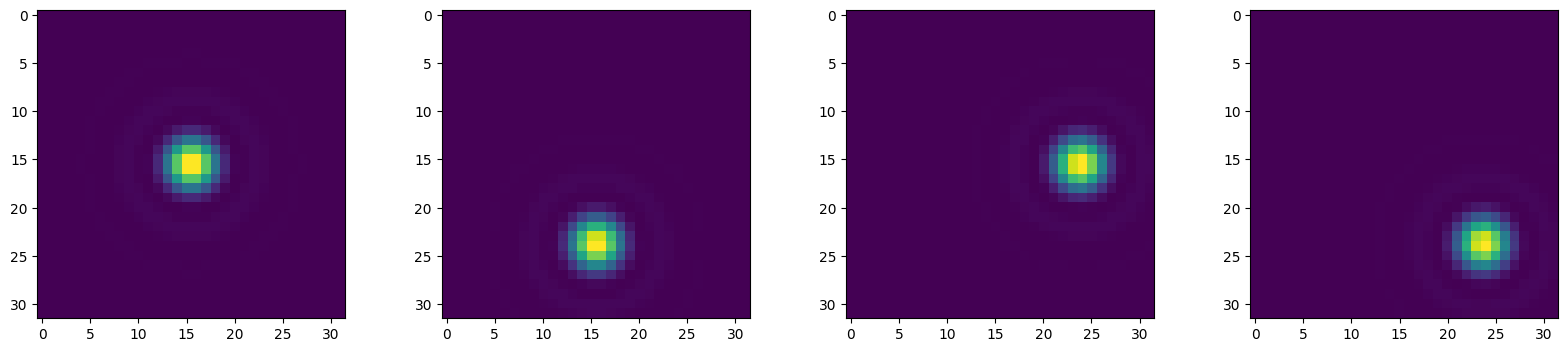

In [4]:
source = dl.PointSource(wavelengths=[1e-6])
optics = dl.utils.simple_optical_system(1, 256, 32, 5e-2)

x = 2e-6
obs = Dither(dithers=np.array([[0, 0], [0, x], [x, 0], [x, x]]))
tel = dl.Instrument(optics, sources=[source], observation=obs)

plt.figure(figsize=(20, 4))
psfs = tel.observe()
for i in range(len(psfs)):
    plt.subplot(1, 4, i+1)
    plt.imshow(psfs[i])
plt.show()

In [5]:
@zdx.filter_jit
@zdx.filter_value_and_grad('dithers')
def loss_fn(model, data):
    return np.sum((model.observe() - data)**2)

In [6]:
model = tel.add('dithers', 5e-7)
loss, grads = loss_fn(model, psfs)

In [7]:
import equinox as eqx
optim = optax.adam(1e-3)
opt_state = optim.init(eqx.filter(model, eqx.is_array))

In [8]:
optim, opt_state = model.get_optimiser(['dithers'], [optax.adam(1e-7)])

losses = []
for i in range(100):
    loss, grads = loss_fn(model, psfs)
    updates, opt_state = optim.update(grads, opt_state)
    model = model.apply_updates(updates)
    losses.append(loss)

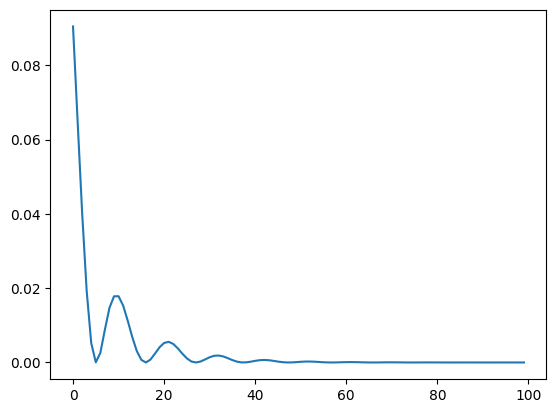

In [9]:
plt.plot(losses)

In [10]:
eqx.tree_serialise_leaves('model.eqx', tel)

In [11]:
from collections import OrderedDict
from jax.typing import ArrayLike

def check_leaf(obj, depth=0):
    t = '  ' * depth
    conatiner_types = (list, tuple, dict, OrderedDict)
    leaf_types = (ArrayLike, bool, complex, float, int, str, type(None))

    # Contianer node
    if isinstance(obj, conatiner_types):
        print(f"{t}Container node of type: {type(obj)}")
        accessor = lambda object, x: object[x]
        if isinstance(obj, (list, tuple)):
            keys = np.arange(len(obj))
        else:
            keys = obj.keys()
        return False, (obj, keys, accessor)
    
    # Leaf node
    elif isinstance(obj, leaf_types):
        print(f"{t}Leaf node of type: {type(obj)}")
        return True, obj
        
    # Class node
    elif hasattr(obj, '__dict__'):
        module = obj.__module__
        print(f"{t}Class node of type: {type(obj)} in module {module}")
        keys = obj.__dict__.keys()
        accessor = lambda object, x: getattr(object, x)
        return False, (obj, keys, accessor)

    # Unknown
    else:
        print(f"{t}Unknown node of type: {type(obj)}")
        return True, obj

In [12]:
def get_structure(obj, depth=0):
    """
    Assumes the original input object is a dLux object
    """
    # structure = (str(type(obj)), {})
    structure = {'type': str(type(obj)), 'parameters': {}}

    # Outer call
    if depth == 0:
        obj_dict = obj.__dict__
        for key in obj_dict.keys():
            # structure[1][key] = get_structure(obj_dict[key], depth+1)
            structure['parameters'][key] = get_structure(obj_dict[key], depth+1)
    
    # Inner calls
    else:
        is_leaf, out = check_leaf(obj, depth)

        # Leaf 
        if is_leaf:
            return str(type(out))
        
        # Node
        else:
            obj, keys, accessor = out

            # Itterate over nodes
            for key in keys:
                # structure[1][key] = get_structure(accessor(obj, key), depth+1)
                structure['parameters'][key] = get_structure(accessor(obj, key), depth+1)
            return structure

    return structure

# def build_structure()

In [ ]:
# def serialise_spec(f, x):
#     if isinstance(x, types.FunctionType):
#         ...  # your custom serialisation here
#     else:
#         return eqx.default_serialise_filter_spec(f, x)
        
# def deserialise_spec(f, x):
#     if isinstance(x, types.FunctionType):
#         ...  # your custom deserialisation here
#     else:
#         return eqx.default_deserialise_filter_spec(f, x)
        
# eqx.tree_serialise_leaves("foo.eqx", foo, filter_spec=serialise_spec)
# new_foo = eqx.tree_deserialise_leaves("foo.eqx", dummy_foo, filter_spec=deserialise_spec)

In [16]:
eqx.filter_eval_shape(dLux.Instrument)

Instrument(
  optics=None,
  scene=None,
  detector=None,
  filter=None,
  observation=None
)

In [19]:
eqx.filter_eval_shape(dLux.core.Optics)


TypeError: Optics.__init__() missing 1 required positional argument: 'layers'

In [14]:
eqx.tree_serialise_leaves("tel.eqx", tel)
structure = get_structure(tel)

  Class node of type: <class 'dLux.core.Optics'> in module dLux.core
    Container node of type: <class 'collections.OrderedDict'>
      Class node of type: <class 'dLux.optics.CreateWavefront'> in module dLux.optics
        Leaf node of type: <class 'str'>
        Leaf node of type: <class 'int'>
        Leaf node of type: <class 'jaxlib.xla_extension.Array'>
        Leaf node of type: <class 'str'>
        Leaf node of type: <class 'str'>
        Container node of type: <class 'dict'>
          Leaf node of type: <class 'str'>
          Leaf node of type: <class 'str'>
          Leaf node of type: <class 'str'>
        Leaf node of type: <class 'str'>
      Class node of type: <class 'dLux.apertures.StaticAperture'> in module dLux.apertures
        Leaf node of type: <class 'str'>
        Leaf node of type: <class 'jaxlib.xla_extension.Array'>
        Leaf node of type: <class 'str'>
        Container node of type: <class 'dict'>
          Leaf node of type: <class 'str'>
        Lea

In [422]:
structure

{'type': "<class 'dLux.core.Instrument'>",
 'parameters': {'optics': {'type': "<class 'dLux.core.Optics'>",
   'parameters': {'layers': {'type': "<class 'collections.OrderedDict'>",
     'parameters': {'CreateWavefront': {'type': "<class 'dLux.optics.CreateWavefront'>",
       'parameters': {'name': "<class 'str'>",
        'npixels': "<class 'int'>",
        'diameter': "<class 'jaxlib.xla_extension.Array'>",
        'wavefront_type': "<class 'str'>"}},
      'CircularAperture': {'type': "<class 'dLux.apertures.StaticAperture'>",
       'parameters': {'name': "<class 'str'>",
        'aperture': "<class 'jaxlib.xla_extension.Array'>"}},
      'NormaliseWavefront': {'type': "<class 'dLux.optics.NormaliseWavefront'>",
       'parameters': {'name': "<class 'str'>"}},
      'AngularMFT': {'type': "<class 'dLux.propagators.AngularMFT'>",
       'parameters': {'name': "<class 'str'>",
        'inverse': "<class 'bool'>",
        'pixel_scale_out': "<class 'jaxlib.xla_extension.Array'>",
   

In [18]:
structure

{'type': "<class 'dLux.core.Instrument'>",
 'parameters': {'optics': {'type': "<class 'dLux.core.Optics'>",
   'parameters': {'layers': {'type': "<class 'collections.OrderedDict'>",
     'parameters': {'CreateWavefront': {'type': "<class 'dLux.optics.CreateWavefront'>",
       'parameters': {'name': "<class 'str'>",
        'npixels': "<class 'int'>",
        'diameter': "<class 'jaxlib.xla_extension.Array'>",
        'wavefront_type': "<class 'str'>",
        '__doc__': "<class 'str'>",
        '__annotations__': {'type': "<class 'dict'>",
         'parameters': {'npixels': "<class 'str'>",
          'diameter': "<class 'str'>",
          'wavefront_type': "<class 'str'>"}},
        '__module__': "<class 'str'>"}},
      'CircularAperture': {'type': "<class 'dLux.apertures.StaticAperture'>",
       'parameters': {'name': "<class 'str'>",
        'aperture': "<class 'jaxlib.xla_extension.Array'>",
        '__doc__': "<class 'str'>",
        '__annotations__': {'type': "<class 'dict'>",

In [430]:
for key, value in structure['parameters'].items():
    print(key, value)


optics {'type': "<class 'dLux.core.Optics'>", 'parameters': {'layers': {'type': "<class 'collections.OrderedDict'>", 'parameters': {'CreateWavefront': {'type': "<class 'dLux.optics.CreateWavefront'>", 'parameters': {'name': "<class 'str'>", 'npixels': "<class 'int'>", 'diameter': "<class 'jaxlib.xla_extension.Array'>", 'wavefront_type': "<class 'str'>"}}, 'CircularAperture': {'type': "<class 'dLux.apertures.StaticAperture'>", 'parameters': {'name': "<class 'str'>", 'aperture': "<class 'jaxlib.xla_extension.Array'>"}}, 'NormaliseWavefront': {'type': "<class 'dLux.optics.NormaliseWavefront'>", 'parameters': {'name': "<class 'str'>"}}, 'AngularMFT': {'type': "<class 'dLux.propagators.AngularMFT'>", 'parameters': {'name': "<class 'str'>", 'inverse': "<class 'bool'>", 'pixel_scale_out': "<class 'jaxlib.xla_extension.Array'>", 'npixels_out': "<class 'int'>", 'shift': "<class 'jaxlib.xla_extension.Array'>", 'pixel_shift': "<class 'bool'>"}}}}}}
detector <class 'NoneType'>
scene {'type': "<cla

In [426]:
structure['parameters']['filter']

"<class 'NoneType'>"

In [428]:
structure['parameters']['optics']


{'type': "<class 'dLux.core.Optics'>",
 'parameters': {'layers': {'type': "<class 'collections.OrderedDict'>",
   'parameters': {'CreateWavefront': {'type': "<class 'dLux.optics.CreateWavefront'>",
     'parameters': {'name': "<class 'str'>",
      'npixels': "<class 'int'>",
      'diameter': "<class 'jaxlib.xla_extension.Array'>",
      'wavefront_type': "<class 'str'>"}},
    'CircularAperture': {'type': "<class 'dLux.apertures.StaticAperture'>",
     'parameters': {'name': "<class 'str'>",
      'aperture': "<class 'jaxlib.xla_extension.Array'>"}},
    'NormaliseWavefront': {'type': "<class 'dLux.optics.NormaliseWavefront'>",
     'parameters': {'name': "<class 'str'>"}},
    'AngularMFT': {'type': "<class 'dLux.propagators.AngularMFT'>",
     'parameters': {'name': "<class 'str'>",
      'inverse': "<class 'bool'>",
      'pixel_scale_out': "<class 'jaxlib.xla_extension.Array'>",
      'npixels_out': "<class 'int'>",
      'shift': "<class 'jaxlib.xla_extension.Array'>",
      'pi

In [429]:
import json

json.dump(structure, open("structure.json", 'w'))

# Ideas:

 - Observations should be stored in a .py file and kept as 'meta data'
 - Create a json file of pytree leaf types in order to reconstruct the high level tree
 - Write custom leaf serialisation for classes and strings
 - Create a initialiser module that creates an 'empty' a pytree for each class
    - This might need meta-data such as the number of leaves in a dictionary

In [17]:
import inspect

inspect.signature(Dither.__init__)

<Signature (self, dithers, name='Observation')>